# Football Valuator MLOps — Modelo

Notebook para entrenar el modelo de predicción del valor de mercado de futbolistas.

**Algoritmo:** Random Forest Regressor

**Target:** `valor_ajustado_2025` (valor en € ajustado a inflación 2025)

**Features:** edad, posición, stats de la ventana, tier de liga, etc.

In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.0f}')

print('✓ Librerías cargadas')

✓ Librerías cargadas


In [17]:
# Cargar el dataset que generamos en el notebook anterior
dataset = pd.read_csv('data/processed/dataset_modelo.csv')

print(f'✓ Dataset cargado: {len(dataset):,} filas')
print(f'\nColumnas:')
print(dataset.columns.tolist())
print(f'\nPrimeras 5 filas:')
dataset.head()

✓ Dataset cargado: 182,966 filas

Columnas:
['player_id', 'name', 'date', 'valor_ajustado_2025', 'market_value_in_eur', 'edad', 'edad_cuadrado', 'position', 'sub_position', 'foot', 'height_in_cm', 'country_of_citizenship', 'es_internacional', 'goles_ventana', 'asistencias_ventana', 'partidos_ventana', 'minutos_ventana', 'amarillas_ventana', 'rojas_ventana', 'goles_por_minuto', 'asistencias_por_minuto', 'ratio_minutos', 'tier_liga']

Primeras 5 filas:


,player_id,name,date,valor_ajustado_2025,market_value_in_eur,edad,edad_cuadrado,position,sub_position,foot,height_in_cm,country_of_citizenship,es_internacional,goles_ventana,asistencias_ventana,partidos_ventana,minutos_ventana,amarillas_ventana,rojas_ventana,goles_por_minuto,asistencias_por_minuto,ratio_minutos,tier_liga
0,4520,Peter Wisgerhof,2012-07-06,"6,250,000",2500000,33,"1,065",Defender,Centre-Back,right,181,Netherlands,False,0,0,1,90,0,0,0,0,1,99
1,30003,Wout Brama,2012-07-06,"12,500,000",5000000,26,670,Midfield,Defensive Midfield,right,176,NaN,False,0,0,1,90,0,0,0,0,1,99
2,47740,Nils Röseler,2012-07-06,"1,000,000",400000,20,416,Defender,Centre-Back,both,190,Germany,False,0,0,1,90,0,0,0,0,1,99
3,60312,Joshua John,2012-07-06,"1,500,000",600000,24,565,Attack,Left Winger,right,175,Aruba,False,1,1,1,45,0,0,0,0,0,99
4,80073,Glynor Plet,2012-07-06,"3,750,000",1500000,25,647,Attack,Centre-Forward,right,194,Netherlands,False,2,1,1,90,0,0,0,0,1,99


In [18]:
# ============================================================
# PREPARAR FEATURES PARA EL MODELO
# ============================================================

# 1. Quitar columnas que NO son features
columnas_no_features = [
    'player_id',           # ID, no aporta
    'name',                # nombre, no aporta
    'date',                # fecha, ya tenemos edad
    'market_value_in_eur', # valor sin ajustar (no es nuestro target)
    'valor_ajustado_2025', # ESTE es el target (lo separamos abajo)
]

# 2. Separar features (X) y target (y)
y = dataset['valor_ajustado_2025']
X = dataset.drop(columns=columnas_no_features)

# 3. Convertir columnas categóricas a números (one-hot encoding)
columnas_categoricas = ['position', 'sub_position', 'foot', 'country_of_citizenship']
X = pd.get_dummies(X, columns=columnas_categoricas, drop_first=True)

# 4. Convertir es_internacional (booleano) a 0/1
X['es_internacional'] = X['es_internacional'].astype(int)

# 5. Manejar nulos en height_in_cm (rellenar con la mediana)
X['height_in_cm'] = X['height_in_cm'].fillna(X['height_in_cm'].median())

print(f'✓ Features preparadas')
print(f'\nNúmero de features: {X.shape[1]}')
print(f'Número de filas: {X.shape[0]:,}')
print(f'\nTipos de datos:')
print(X.dtypes.value_counts())

✓ Features preparadas

Número de features: 209
Número de filas: 182,966

Tipos de datos:
bool       195
int64        8
float64      6
Name: count, dtype: int64


In [19]:
# ============================================================
# DIVIDIR EN TRAIN / TEST
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% para test
    random_state=42       # semilla fija para reproducibilidad
)

print(f'✓ Datos divididos:')
print(f'   Entrenamiento: {len(X_train):,} filas ({len(X_train)/len(X)*100:.0f}%)')
print(f'   Test:          {len(X_test):,} filas ({len(X_test)/len(X)*100:.0f}%)')

print(f'\nEstadísticas del target (valor):')
print(f'   Train - mediana: {y_train.median():,.0f} €')
print(f'   Test  - mediana: {y_test.median():,.0f} €')

✓ Datos divididos:
   Entrenamiento: 146,372 filas (80%)
   Test:          36,594 filas (20%)

Estadísticas del target (valor):
   Train - mediana: 1,931,818 €
   Test  - mediana: 1,967,213 €


In [20]:
# ============================================================
# ENTRENAR RANDOM FOREST
# ============================================================

print('🌲 Entrenando Random Forest...')

modelo = RandomForestRegressor(
    n_estimators=100,    # 100 árboles
    max_depth=20,        # profundidad máxima por árbol
    min_samples_split=10, # mínimo de muestras para dividir un nodo
    n_jobs=-1,           # usar todos los cores del Mac
    random_state=42      # reproducibilidad
)

modelo.fit(X_train, y_train)

print('✓ Modelo entrenado')

🌲 Entrenando Random Forest...


KeyboardInterrupt: 

In [ ]:
# ============================================================
# EVALUAR EL MODELO
# ============================================================

# Hacer predicciones sobre el conjunto de test
y_pred = modelo.predict(X_test)

# Calcular métricas
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print('=' * 50)
print('MÉTRICAS DEL MODELO')
print('=' * 50)
print(f'\nMAE (Mean Absolute Error):  {mae:,.0f} €')
print(f'   → De media, el modelo se equivoca en {mae/1e6:.2f} M€')

print(f'\nRMSE (Root Mean Squared Error): {rmse:,.0f} €')
print(f'   → Penaliza más los errores grandes')

print(f'\nR² (Coeficiente de determinación): {r2:.4f}')
print(f'   → El modelo explica el {r2*100:.1f}% de la variación del valor')

# Comparación con el valor mediano para contextualizar
mediana_test = y_test.median()
print(f'\n📊 Para contexto:')
print(f'   Valor mediano de los jugadores en test: {mediana_test:,.0f} €')
print(f'   Error relativo del MAE: {mae/mediana_test*100:.0f}% del valor mediano')

MÉTRICAS DEL MODELO

MAE (Mean Absolute Error):  4,435,435 €
   → De media, el modelo se equivoca en 4.44 M€

RMSE (Root Mean Squared Error): 9,148,744 €
   → Penaliza más los errores grandes

R² (Coeficiente de determinación): 0.5567
   → El modelo explica el 55.7% de la variación del valor

📊 Para contexto:
   Valor mediano de los jugadores en test: 1,967,213 €
   Error relativo del MAE: 225% del valor mediano


## Iteración 2: Transformación logarítmica

El primer modelo da R²=0.56 y MAE=4.4M €. Analizando, el problema es que el target tiene un rango de 20.000:1 (de 10K€ a 200M€), lo que hace muy difícil al modelo aprender patrones consistentes.

**Solución**: aplicar transformación logarítmica al target (`log1p`). Es la técnica estándar para variables tipo precio porque:
- Comprime el rango (de millones a unos pocos números)
- Hace que los errores sean proporcionales (mejor para precios)
- Reduce el efecto de outliers como Mbappé (180M€)

In [ ]:
# ============================================================
# TRANSFORMACIÓN LOGARÍTMICA DEL TARGET
# ============================================================
# log1p() = log(1 + x), evita problemas con valores cercanos a 0

# Crear el target transformado
y_log = np.log1p(y)

print('Comparación del target:')
print(f'\n  ORIGINAL:')
print(f'    Mínimo:  {y.min():>15,.0f} €')
print(f'    Mediana: {y.median():>15,.0f} €')
print(f'    Máximo:  {y.max():>15,.0f} €')
print(f'    Rango:   {y.max() - y.min():>15,.0f} €')

print(f'\n  LOG TRANSFORMADO:')
print(f'    Mínimo:  {y_log.min():.2f}')
print(f'    Mediana: {y_log.median():.2f}')
print(f'    Máximo:  {y_log.max():.2f}')
print(f'    Rango:   {y_log.max() - y_log.min():.2f}')

Comparación del target:

  ORIGINAL:
    Mínimo:           10,000 €
    Mediana:       1,967,213 €
    Máximo:      295,081,967 €
    Rango:       295,071,967 €

  LOG TRANSFORMADO:
    Mínimo:  9.21
    Mediana: 14.49
    Máximo:  19.50
    Rango:   10.29


In [ ]:
# ============================================================
# REENTRENAR EL MODELO CON EL TARGET LOG-TRANSFORMADO
# ============================================================

# Volver a hacer el split usando y_log
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log,
    test_size=0.2,
    random_state=42
)

# También guardamos el y_test SIN log (lo necesitaremos para evaluar en € reales)
_, _, y_train_real, y_test_real = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print('🌲 Entrenando Random Forest con log target...')

modelo_log = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_split=10,
    n_jobs=-1,
    random_state=42
)

modelo_log.fit(X_train, y_train_log)

print('✓ Modelo entrenado')

🌲 Entrenando Random Forest con log target...
✓ Modelo entrenado


In [ ]:
# ============================================================
# EVALUAR EL MODELO LOG
# ============================================================

# Predecir en escala log
y_pred_log = modelo_log.predict(X_test)

# Convertir las predicciones de vuelta a € reales (deshacer el log)
y_pred_real = np.expm1(y_pred_log)

# Calcular métricas en € reales
mae = mean_absolute_error(y_test_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
r2 = r2_score(y_test_real, y_pred_real)

# También calculamos R² en escala log (suele ser más alto)
r2_log = r2_score(y_test_log, y_pred_log)

print('=' * 50)
print('MÉTRICAS DEL MODELO LOG')
print('=' * 50)
print(f'\nMAE: {mae:,.0f} €')
print(f'RMSE: {rmse:,.0f} €')
print(f'R² (en € reales): {r2:.4f}')
print(f'R² (en escala log): {r2_log:.4f}  ← más representativo')

print(f'\n📊 Para contexto:')
print(f'   Valor mediano: {y_test_real.median():,.0f} €')
print(f'   Error relativo MAE: {mae/y_test_real.median()*100:.0f}% de la mediana')

MÉTRICAS DEL MODELO LOG

MAE: 4,111,205 €
RMSE: 9,945,214 €
R² (en € reales): 0.4761
R² (en escala log): 0.6367  ← más representativo

📊 Para contexto:
   Valor mediano: 1,967,213 €
   Error relativo MAE: 209% de la mediana


In [ ]:
# ============================================================
# REDUCIR FEATURES (agrupar países raros en "Otros")
# ============================================================

# Volvemos al dataset original
y = dataset['valor_ajustado_2025']
y_log = np.log1p(y)

X = dataset.drop(columns=[
    'player_id', 'name', 'date', 'market_value_in_eur', 'valor_ajustado_2025'
])

# Para country_of_citizenship: quedarse solo con los 30 más comunes
top_paises = X['country_of_citizenship'].value_counts().head(30).index
X['country_of_citizenship'] = X['country_of_citizenship'].where(
    X['country_of_citizenship'].isin(top_paises),
    'OTROS'
)

# Para sub_position: quedarse solo con las 15 más comunes
top_subpos = X['sub_position'].value_counts().head(15).index
X['sub_position'] = X['sub_position'].where(
    X['sub_position'].isin(top_subpos),
    'OTRA'
)

# One-hot encoding
columnas_categoricas = ['position', 'sub_position', 'foot', 'country_of_citizenship']
X = pd.get_dummies(X, columns=columnas_categoricas, drop_first=True)

# Convertir es_internacional
X['es_internacional'] = X['es_internacional'].astype(int)

# Rellenar nulos
X['height_in_cm'] = X['height_in_cm'].fillna(X['height_in_cm'].median())

print(f'✓ Features reducidas')
print(f'   Features ANTES: 209')
print(f'   Features AHORA: {X.shape[1]}')

✓ Features reducidas
   Features ANTES: 209
   Features AHORA: 63


In [ ]:
# ============================================================
# MODELO OPTIMIZADO (con features reducidas + log target)
# ============================================================

# 1. Split
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)
_, _, y_train_real, y_test_real = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. Entrenar con más árboles y mejores parámetros
print('🌲 Entrenando Random Forest optimizado...')

modelo_opt = RandomForestRegressor(
    n_estimators=200,         # más árboles (más preciso)
    max_depth=25,             # algo más de profundidad
    min_samples_split=5,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42
)
modelo_opt.fit(X_train, y_train_log)

# 3. Predecir y deshacer el log
y_pred_log = modelo_opt.predict(X_test)
y_pred_real = np.expm1(y_pred_log)

# 4. Métricas
mae = mean_absolute_error(y_test_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
r2 = r2_score(y_test_real, y_pred_real)
r2_log = r2_score(y_test_log, y_pred_log)

print('\n' + '=' * 50)
print('MÉTRICAS DEL MODELO OPTIMIZADO')
print('=' * 50)
print(f'\nMAE: {mae:,.0f} €')
print(f'RMSE: {rmse:,.0f} €')
print(f'R² (en € reales): {r2:.4f}')
print(f'R² (escala log): {r2_log:.4f}')
print(f'\nError relativo MAE: {mae/y_test_real.median()*100:.0f}% de la mediana')

# 5. Top 15 features más importantes
importancias = pd.DataFrame({
    'feature': X.columns,
    'importancia': modelo_opt.feature_importances_
}).sort_values('importancia', ascending=False).head(15)

print('\n' + '=' * 50)
print('TOP 15 FEATURES MÁS IMPORTANTES')
print('=' * 50)
for idx, row in importancias.iterrows():
    print(f'  {row["feature"]:<35} {row["importancia"]*100:>5.1f}%')

🌲 Entrenando Random Forest optimizado...

MÉTRICAS DEL MODELO OPTIMIZADO

MAE: 4,111,110 €
RMSE: 9,949,037 €
R² (en € reales): 0.4757
R² (escala log): 0.6355

Error relativo MAE: 209% de la mediana

TOP 15 FEATURES MÁS IMPORTANTES
  tier_liga                            36.2%
  minutos_ventana                      14.8%
  edad_cuadrado                         7.2%
  edad                                  7.2%
  ratio_minutos                         4.5%
  es_internacional                      4.5%
  height_in_cm                          4.2%
  goles_ventana                         3.1%
  goles_por_minuto                      1.9%
  asistencias_por_minuto                1.8%
  partidos_ventana                      1.7%
  asistencias_ventana                   1.3%
  amarillas_ventana                     1.2%
  country_of_citizenship_OTROS          0.6%
  country_of_citizenship_Brazil         0.6%


MÉTRICAS POR RANGO DE VALOR
Categoría                     N             MAE   % error medio
-----------------------------------------------------------------
1. Bajo (<1M)            12,639       559,270 €            123%
2. Medio (1-5M)          13,193     1,787,652 €             83%
3. Alto (5-20M)           7,583     5,490,553 €             62%
4. Élite (20-50M)         2,452    17,378,743 €             62%
5. Estrella (>50M)          727    48,887,643 €             71%


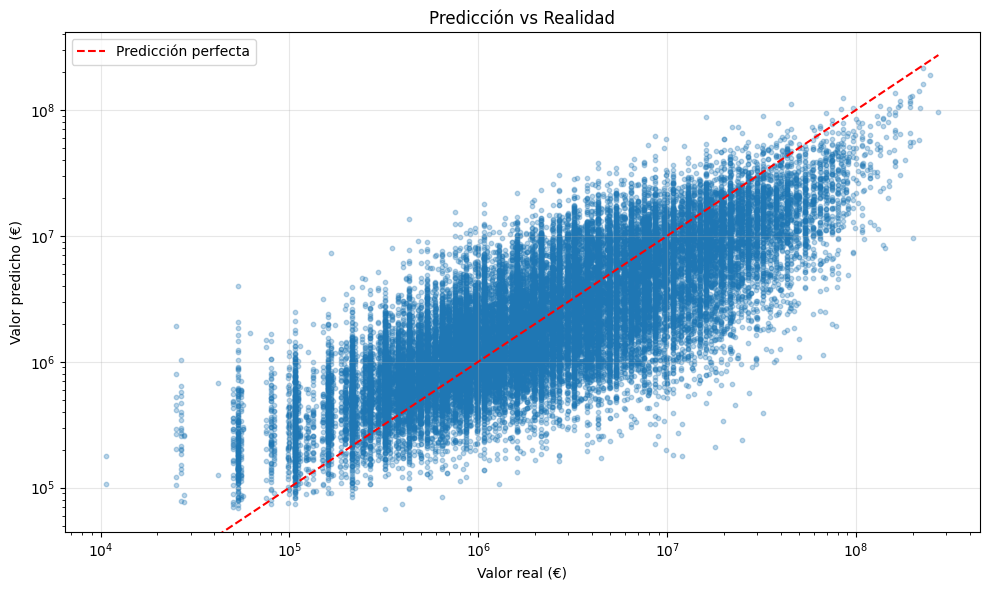

In [ ]:
# ============================================================
# EVALUACIÓN SEGMENTADA POR RANGO DE VALOR
# ============================================================

# Crear categorías de valor
def categorizar(valor):
    if valor < 1_000_000:
        return '1. Bajo (<1M)'
    elif valor < 5_000_000:
        return '2. Medio (1-5M)'
    elif valor < 20_000_000:
        return '3. Alto (5-20M)'
    elif valor < 50_000_000:
        return '4. Élite (20-50M)'
    else:
        return '5. Estrella (>50M)'

categorias = y_test_real.apply(categorizar)

# Métricas por categoría
print('=' * 65)
print('MÉTRICAS POR RANGO DE VALOR')
print('=' * 65)
print(f'{"Categoría":<22} {"N":>8} {"MAE":>15} {"% error medio":>15}')
print('-' * 65)

for cat in sorted(categorias.unique()):
    mask = categorias == cat
    if mask.sum() == 0:
        continue
    mae_cat = mean_absolute_error(y_test_real[mask], y_pred_real[mask])
    pct_error = (mae_cat / y_test_real[mask].median()) * 100
    print(f'{cat:<22} {mask.sum():>8,} {mae_cat:>13,.0f} € {pct_error:>14.0f}%')

# Gráfico: predicción vs realidad
plt.figure(figsize=(10, 6))
plt.scatter(y_test_real, y_pred_real, alpha=0.3, s=10)
plt.plot([0, y_test_real.max()], [0, y_test_real.max()], 'r--', label='Predicción perfecta')
plt.xlabel('Valor real (€)')
plt.ylabel('Valor predicho (€)')
plt.title('Predicción vs Realidad')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# MODELO ALTERNATIVO: GRADIENT BOOSTING
# ============================================================
from sklearn.ensemble import GradientBoostingRegressor

print('🚀 Entrenando Gradient Boosting... (puede tardar 2-3 min)')

modelo_gb = GradientBoostingRegressor(
    n_estimators=500,        # 500 árboles secuenciales
    max_depth=6,             # menos profundo que RF (los árboles son más débiles, pero se complementan)
    learning_rate=0.05,      # cuánto aprende cada árbol
    min_samples_split=10,
    min_samples_leaf=5,
    subsample=0.8,           # cada árbol entrena con 80% aleatorio (regularización)
    random_state=42
)

modelo_gb.fit(X_train, y_train_log)

# Predicciones
y_pred_log_gb = modelo_gb.predict(X_test)
y_pred_real_gb = np.expm1(y_pred_log_gb)

# Métricas
mae_gb = mean_absolute_error(y_test_real, y_pred_real_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test_real, y_pred_real_gb))
r2_gb = r2_score(y_test_real, y_pred_real_gb)
r2_log_gb = r2_score(y_test_log, y_pred_log_gb)

print('\n' + '=' * 50)
print('MÉTRICAS GRADIENT BOOSTING')
print('=' * 50)
print(f'\nMAE: {mae_gb:,.0f} €')
print(f'RMSE: {rmse_gb:,.0f} €')
print(f'R² (escala €): {r2_gb:.4f}')
print(f'R² (escala log): {r2_log_gb:.4f}')

# Comparar con Random Forest
print('\n' + '=' * 50)
print('COMPARATIVA RF vs GB')
print('=' * 50)
print(f'{"Modelo":<25} {"MAE":>15} {"R² log":>10}')
print(f'{"Random Forest":<25} {mae:>13,.0f} € {r2_log:>10.4f}')
print(f'{"Gradient Boosting":<25} {mae_gb:>13,.0f} € {r2_log_gb:>10.4f}')

# Métricas por rango de valor
print('\n' + '=' * 65)
print('MÉTRICAS GB POR RANGO DE VALOR')
print('=' * 65)
print(f'{"Categoría":<22} {"N":>8} {"MAE":>15} {"% error":>15}')
print('-' * 65)

for cat in sorted(categorias.unique()):
    mask = categorias == cat
    if mask.sum() == 0:
        continue
    mae_cat = mean_absolute_error(y_test_real[mask], y_pred_real_gb[mask])
    pct_error = (mae_cat / y_test_real[mask].median()) * 100
    print(f'{cat:<22} {mask.sum():>8,} {mae_cat:>13,.0f} € {pct_error:>14.0f}%')

🚀 Entrenando Gradient Boosting... (puede tardar 2-3 min)

MÉTRICAS GRADIENT BOOSTING

MAE: 4,000,196 €
RMSE: 9,642,856 €
R² (escala €): 0.5075
R² (escala log): 0.6499

COMPARATIVA RF vs GB
Modelo                                MAE     R² log
Random Forest                 4,111,110 €     0.6355
Gradient Boosting             4,000,196 €     0.6499

MÉTRICAS GB POR RANGO DE VALOR
Categoría                     N             MAE         % error
-----------------------------------------------------------------
1. Bajo (<1M)            12,639       538,285 €            118%
2. Medio (1-5M)          13,193     1,712,694 €             80%
3. Alto (5-20M)           7,583     5,444,116 €             61%
4. Élite (20-50M)         2,452    17,136,087 €             61%
5. Estrella (>50M)          727    46,332,594 €             67%


In [ ]:
# ============================================================
# GUARDAR MODELO FINAL
# ============================================================
import joblib
import os

# Crear carpeta para modelos
os.makedirs('models', exist_ok=True)

# El modelo final es Gradient Boosting (mejor de los probados)
joblib.dump(modelo_gb, 'models/modelo_final.pkl')
joblib.dump(X.columns.tolist(), 'models/features.pkl')

print('✓ Modelo guardado en models/modelo_final.pkl')
print(f'✓ {len(X.columns)} features guardadas en models/features.pkl')

# Resumen final
print('\n' + '=' * 50)
print('RESUMEN FINAL DEL MODELO')
print('=' * 50)
print(f'Algoritmo: Gradient Boosting Regressor')
print(f'Target: log(valor_ajustado_2025)')
print(f'Features: {len(X.columns)}')
print(f'\nMétricas en test set ({len(X_test):,} jugadores):')
print(f'  MAE:           {mae_gb:>15,.0f} €')
print(f'  R² (en €):     {r2_gb:>15.4f}')
print(f'  R² (escala log): {r2_log_gb:>13.4f}')

✓ Modelo guardado en models/modelo_final.pkl
✓ 63 features guardadas en models/features.pkl

RESUMEN FINAL DEL MODELO
Algoritmo: Gradient Boosting Regressor
Target: log(valor_ajustado_2025)
Features: 63

Métricas en test set (36,594 jugadores):
  MAE:                 4,000,196 €
  R² (en €):              0.5075
  R² (escala log):        0.6499


In [21]:
# ============================================================
# PROBAR GB CON LAS 209 FEATURES ORIGINALES
# ============================================================

# Volver a preparar X con TODAS las features (sin agrupar países raros)
y_full = dataset['valor_ajustado_2025']
y_log_full = np.log1p(y_full)

X_full = dataset.drop(columns=[
    'player_id', 'name', 'date', 'market_value_in_eur', 'valor_ajustado_2025'
])

# One-hot SIN agrupar países raros
X_full = pd.get_dummies(X_full, columns=['position', 'sub_position', 'foot', 'country_of_citizenship'], drop_first=True)
X_full['es_internacional'] = X_full['es_internacional'].astype(int)
X_full['height_in_cm'] = X_full['height_in_cm'].fillna(X_full['height_in_cm'].median())

print(f'Features con todo: {X_full.shape[1]}')

# Split
X_train_f, X_test_f, y_train_log_f, y_test_log_f = train_test_split(
    X_full, y_log_full, test_size=0.2, random_state=42
)
_, _, _, y_test_real_f = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)

# Entrenar GB
print('🚀 Entrenando GB con todas las features...')
modelo_gb_full = GradientBoostingRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    min_samples_split=10,
    min_samples_leaf=5,
    subsample=0.8,
    random_state=42
)
modelo_gb_full.fit(X_train_f, y_train_log_f)

y_pred_log_f = modelo_gb_full.predict(X_test_f)
y_pred_real_f = np.expm1(y_pred_log_f)

mae_full = mean_absolute_error(y_test_real_f, y_pred_real_f)
r2_full = r2_score(y_test_real_f, y_pred_real_f)
r2_log_full = r2_score(y_test_log_f, y_pred_log_f)

print(f'\nMAE: {mae_full:,.0f} €')
print(f'R² (€): {r2_full:.4f}')
print(f'R² (log): {r2_log_full:.4f}')

print('\n' + '=' * 60)
print('COMPARATIVA FINAL')
print('=' * 60)
print(f'{"Modelo":<35} {"MAE":>13} {"R² log":>10}')
print(f'{"GB (63 features)":<35} {mae_gb:>11,.0f} € {r2_log_gb:>10.4f}')
print(f'{"GB (209 features)":<35} {mae_full:>11,.0f} € {r2_log_full:>10.4f}')

Features con todo: 209
🚀 Entrenando GB con todas las features...

MAE: 3,991,461 €
R² (€): 0.5084
R² (log): 0.6509

COMPARATIVA FINAL
Modelo                                        MAE     R² log
GB (63 features)                      4,000,196 €     0.6499
GB (209 features)                     3,991,461 €     0.6509
